In [2]:
import pandas as pd
import re

In [3]:
f = open("chat_with_nirjal_vanja.txt", "r", encoding="utf-8")

In [4]:
data = f.read()

In [5]:
date_pattern = r"\d{1,2}/\d{1,2}/\d{2,4},\s\d{1,2}:\d{2}(?:\s(?:am|pm|AM|PM))?"
entry_pattern = (
    r"(?s)^" +
    r"(" + date_pattern + r")" +
    r"\s-\s([^:]+):\s(.*?)" +
    r"(?=\n" + date_pattern + r"\s-\s[^:]+:\s|\Z)"
)

In [6]:
entries = re.findall(entry_pattern, data, flags=re.M)
messages = [f"{name}: {msg}" for _, name, msg in entries]
messages[:10]

['GauravDulal: Vanja',
 'GauravDulal: ',
 'Nirjal Vanja: <Media omitted>',
 'GauravDulal: Act as a world-class numerologist. You are direct, clear and honest like a sword, but also kind and practical.\n\nFirst, ask me in ONE message: 1) What is your full date of birth?\n\n(DD-MM-YYYY or Month Day, Year) 2) What is your full name in English as on official documents? (Optional) 3) What is your gender (only to adjust pronouns, not predictions)? After I answer, do a full numerology "SWAT Analysis" of my life. Do all of this:\n\n1. Calculate and show:\n\n\n\nLife Path Number\n\n\n-Destiny/Expression Number (if name given)\n\nSoul Urge/Heart\'s Desire Number\n\n(if name given)\n\nPersonality Number (if name given)\n\n\n-Birthday Number\n\nMaturity Number\n\n\nFor each number:\n\nShow the calculation briefly.\n\nGive a short title, e.g. "Life Path\n\n\n7-The Seeker".\n2. Explain in depth:\n\n-Who I am at my core (personality + essence).\n\n-My main life purpose and repeating life themes.\n\nM

In [7]:
dates = [
    re.sub(r"\s(?:am|pm|AM|PM)$", "", d.replace("\u202f", " ")) + " - "
    for d, _, _ in entries
]
len(dates)
dates[:5]

['27/05/25, 9:05 - ',
 '27/05/25, 9:05 - ',
 '28/05/25, 1:32 - ',
 '18/12/25, 5:23 - ',
 '18/12/25, 6:09 - ']

In [8]:
df = pd.DataFrame({"user_message": messages, "message_date": dates})
# convert message_date type
clean_dates = df["message_date"].str.replace(r"\s-\s$", "", regex=True)
df["message_date"] = pd.to_datetime(clean_dates, format="mixed", dayfirst=True)
df.rename(columns={"message_date": "date"}, inplace=True)
df.head()

,user_message,date
0,GauravDulal: Vanja,2025-05-27 09:05:00
1,GauravDulal:,2025-05-27 09:05:00
2,Nirjal Vanja: <Media omitted>,2025-05-28 01:32:00
3,GauravDulal: Act as a world-class numerologist...,2025-12-18 05:23:00
4,Nirjal Vanja: <Media omitted>,2025-12-18 06:09:00


In [9]:
df.shape

(680, 2)

In [10]:
# separate users and messages
users = []
message_texts = []
for text in df["user_message"]:
    entry = text.split(": ", 1)
    if len(entry) == 2:
        users.append(entry[0])
        message_texts.append(entry[1])
    else:
        users.append("Unknown")
        message_texts.append(entry[0])
df["user"] = users
df["message"] = [m.replace("\n", " ").strip() for m in message_texts]
# keep only required columns and drop empty/media-omitted messages
final_df = df[["date", "user", "message"]]
final_df = final_df[final_df["message"] != ""]
final_df = final_df[final_df["message"].str.lower() != "<media omitted>"]
final_df.head()

,date,user,message
0,2025-05-27 09:05:00,GauravDulal,Vanja
3,2025-12-18 05:23:00,GauravDulal,Act as a world-class numerologist. You are dir...
22,2025-12-18 06:12:00,GauravDulal,Naak chai lado aayecha
23,2025-12-18 06:13:00,GauravDulal,Milauna parla
24,2025-12-18 06:13:00,GauravDulal,Halka


In [11]:
df['year'] = df['date'].dt.year

In [12]:
df.head()

,user_message,date,user,message,year
0,GauravDulal: Vanja,2025-05-27 09:05:00,GauravDulal,Vanja,2025
1,GauravDulal:,2025-05-27 09:05:00,GauravDulal,,2025
2,Nirjal Vanja: <Media omitted>,2025-05-28 01:32:00,Nirjal Vanja,<Media omitted>,2025
3,GauravDulal: Act as a world-class numerologist...,2025-12-18 05:23:00,GauravDulal,Act as a world-class numerologist. You are dir...,2025
4,Nirjal Vanja: <Media omitted>,2025-12-18 06:09:00,Nirjal Vanja,<Media omitted>,2025


In [13]:
df['month'] = df['date'].dt.month_name()

In [14]:
df['day'] = df['date'].dt.day

In [15]:
df['hour'] = df['date'].dt.hour

In [16]:
df['minute'] = df['date'].dt.minute

In [17]:
df.head()

,user_message,date,user,message,year,month,day,hour,minute
0,GauravDulal: Vanja,2025-05-27 09:05:00,GauravDulal,Vanja,2025,May,27,9,5
1,GauravDulal:,2025-05-27 09:05:00,GauravDulal,,2025,May,27,9,5
2,Nirjal Vanja: <Media omitted>,2025-05-28 01:32:00,Nirjal Vanja,<Media omitted>,2025,May,28,1,32
3,GauravDulal: Act as a world-class numerologist...,2025-12-18 05:23:00,GauravDulal,Act as a world-class numerologist. You are dir...,2025,December,18,5,23
4,Nirjal Vanja: <Media omitted>,2025-12-18 06:09:00,Nirjal Vanja,<Media omitted>,2025,December,18,6,9


In [18]:
df.drop(columns=['user_message'], inplace=True)

In [19]:
df.head()

,date,user,message,year,month,day,hour,minute
0,2025-05-27 09:05:00,GauravDulal,Vanja,2025,May,27,9,5
1,2025-05-27 09:05:00,GauravDulal,,2025,May,27,9,5
2,2025-05-28 01:32:00,Nirjal Vanja,<Media omitted>,2025,May,28,1,32
3,2025-12-18 05:23:00,GauravDulal,Act as a world-class numerologist. You are dir...,2025,December,18,5,23
4,2025-12-18 06:09:00,Nirjal Vanja,<Media omitted>,2025,December,18,6,9


In [20]:
words = 0
for message in df['message']:
    message_words = message.split()
    words += len(message_words)

print(f"Total words: {words}")

Total words: 2978


Extracting the urls

In [21]:
from urlextract import URLExtract
count = 0
extractor = URLExtract()
for message in df['message']:
    urls = extractor.find_urls(message)
    count += len(urls)
print(f"Total urls: {count}")

Total urls: 3


top 5 users with most messages

In [22]:
x = df['user'].value_counts().head()

In [23]:
import matplotlib.pyplot as plt 

In [24]:
name = x.index
count = x.values 

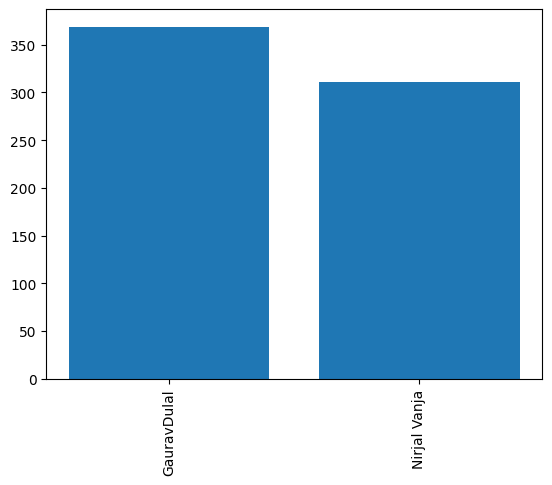

In [25]:
plt.bar(name,count)
plt.xticks(rotation = 'vertical')
plt.show()

In [26]:
round((df['user'].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={"user":"Name","count":"percent"})

,Name,percent
0,GauravDulal,54.26
1,Nirjal Vanja,45.74


most used words

In [36]:
temp = df[df['user'] != 'group_notification']
temp = temp[temp['message'] != 'Media omitted>']

In [28]:
words = []

for message in df['message']:
    words.extend(message.split())


In [30]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(20))

,0,1
0,omitted>,161
1,<Media,159
2,ta,50
3,ma,50
4,muji,39
5,ko,37
6,ho,36
7,k,31
8,vanja,30
9,thik,22
